In [1]:
# ===== Cell 1: Imports =====

import requests
import pandas as pd
import time
import os
from datetime import datetime
import torch
from torch.utils.data import Dataset
import numpy as np
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Subset, random_split
import torch.optim as optim
import matplotlib.pyplot as plt
import sys
import torch.nn as nn
import torch.nn.init as init
from pathlib import Path

from src.models.TFT import TFTLoss, StockTFT


# ===== End of Cell 1 =====

C:\Users\omrym\anaconda3\envs\deep_learn\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===== Cell 2: Data Acquisition & Dataset Class =====

# Constants for the TFT Architecture
SEQ_LEN = 55    # 55-day lookback window
INPUT_DIM = 6   # O, H, L, C, V_norm, V_dollar
CLASSES = 3     # Sell (0), Neutral (1), Buy (2)

# --- SMART PATH SELECTION ---
# Detect environment: if CUDA is available, we assume Colab.
# Otherwise, we check for the local relative path.

RESULTS_DIR = Path("../results/best_runs")
os.makedirs(RESULTS_DIR, exist_ok=True)

# --- SMART PATH SELECTION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    MASTER_PATH = Path("/content/master_dataset_OHLCV.pt")
    print("🤖 Environment: Google Colab (GPU) detected.")
else:
    MASTER_PATH = Path("../data/master_dataset_OHLCV.pt")
    print("💻 Environment: Local Machine (CPU) detected.")

class MasterStockDataset(Dataset):
    def __init__(self, master_file_path):
        if not master_file_path.exists():
            raise FileNotFoundError(f"❌ Master file missing: {master_file_path}")

        print(f"📂 Loading: {master_file_path.name}")
        # weights_only=False is required to load the dictionary structure
        data_list = torch.load(master_file_path, weights_only=False)

        # Vectorized extraction for performance
        self.X = torch.tensor(np.array([s['x'] for s in data_list]), dtype=torch.float32)
        self.y = torch.tensor(np.array([s['y'] for s in data_list]), dtype=torch.long)

        # FIXED: Using 'window_start' to match the actual keys in metadata
        self.tickers = [s['metadata']['ticker'] for s in data_list]
        self.dates = [s['metadata']['window_start'] for s in data_list]

        print(f"✅ Loaded {len(self.y)} windows across {len(set(self.tickers))} unique tickers.")

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

    def get_class_weights(self):
        counts = np.bincount(self.y.numpy(), minlength=3)
        # Weight = Total / (Num_Classes * Class_Count)
        weights = len(self.y) / (3 * counts)
        return torch.tensor(weights, dtype=torch.float32), counts

# 1. Initialize Dataset
full_dataset = MasterStockDataset(MASTER_PATH)
class_weights, global_counts = full_dataset.get_class_weights()

# 2. Perform 70/15/15 Split
train_len = int(0.7 * len(full_dataset))
val_len = int(0.15 * len(full_dataset))
test_len = len(full_dataset) - train_len - val_len

train_ds, val_ds, test_ds = random_split(
    full_dataset, [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(42)
)

# 3. Print Detailed Statistics
def print_dataset_stats(name, subset):
    # Extract labels from the master tensor using subset indices
    subset_labels = full_dataset.y[subset.indices].numpy()
    counts = np.bincount(subset_labels, minlength=3)
    total = len(subset_labels)

    print(f"{name:<10} | Samples: {total:<6,}")
    print(f"           Distribution: Sell: {counts[0]:<5} ({counts[0]/total:>5.1%}) | "
          f"Neu: {counts[1]:<5} ({counts[1]/total:>5.1%}) | "
          f"Buy: {counts[2]:<5} ({counts[2]/total:>5.1%})")

print("\n📊 --- Dataset Distribution Audit ---")
print_dataset_stats("TRAIN", train_ds)
print_dataset_stats("VAL", val_ds)
print_dataset_stats("TEST", test_ds)

print(f"\n⚖️ --- Computed Loss Weights (Inverse Frequency) ---")
print(f"Class 0 (Sell): {class_weights[0]:.4f}")
print(f"Class 1 (Neu):  {class_weights[1]:.4f}")
print(f"Class 2 (Buy):  {class_weights[2]:.4f}")

# ===== End of Cell 2 =====

💻 Environment: Local Machine (CPU) detected.
📂 Loading: master_dataset_OHLCV.pt
✅ Loaded 72143 windows across 48 unique tickers.

📊 --- Dataset Distribution Audit ---
TRAIN      | Samples: 50,500
           Distribution: Sell: 14098 (27.9%) | Neu: 20747 (41.1%) | Buy: 15655 (31.0%)
VAL        | Samples: 10,821
           Distribution: Sell: 3007  (27.8%) | Neu: 4493  (41.5%) | Buy: 3321  (30.7%)
TEST       | Samples: 10,822
           Distribution: Sell: 3011  (27.8%) | Neu: 4419  (40.8%) | Buy: 3392  (31.3%)

⚖️ --- Computed Loss Weights (Inverse Frequency) ---
Class 0 (Sell): 1.1954
Class 1 (Neu):  0.8108
Class 2 (Buy):  1.0751


In [8]:
import torch.optim as optim
from datetime import datetime
from tqdm.auto import tqdm
import numpy as np

# --- 1. Hyperparameters ---
M_EPOCHS = 80
HIDDEN_DIM = 128
LR = 0.0005
GAMMA = 1.5
DW = 0.5
BATCH_SIZE = 128

# --- 2. Data Preparation (70/15/15 Split) ---
train_len = int(0.7 * len(full_dataset))
val_len = int(0.15 * len(full_dataset))
test_len = len(full_dataset) - train_len - val_len

train_ds, val_ds, test_ds = random_split(
    full_dataset, [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# --- 3. Initialization ---
model = StockTFT(input_dim=6, hidden_dim=HIDDEN_DIM, n_heads=8, output_dim=3).to(device)
criterion = TFTLoss(alpha=class_weights.to(device), gamma=GAMMA, directional_weight=DW)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Adaptive learning rate: drops if val_loss doesn't improve for 10 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

history = {
    "train_loss": [], "val_loss": [], "test_loss": [],
    "train_acc": [], "val_acc": [], "test_acc": []
}

# --- 4. Evaluation Helper ---
def evaluate(loader):
    model.eval()
    loss_sum, correct = 0, 0
    all_preds, all_true = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss_sum += criterion(out, y).item()
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(y.cpu().numpy())
    return loss_sum/len(loader), correct/len(loader.dataset), np.array(all_preds), np.array(all_true)

# --- 5. Training Loop ---
print(f"🚀 Training {M_EPOCHS} Epochs | Batch: {BATCH_SIZE} | H: {HIDDEN_DIM} | Heads: 8 | Device: {device}")
print(f"{'Epoch':<8} | {'TrLoss':<7} | {'ValLoss':<7} | {'TsLoss':<7} | {'TrAcc':<7} | {'ValAcc':<7} | {'TsAcc':<7}")
print("-" * 85)

best_v_loss = float('inf')
timestamp_start = datetime.now().strftime("%Y%m%d_%H%M")
pbar = tqdm(range(M_EPOCHS), desc="🚀 Progress", colour='green')

for epoch in pbar:
    # --- Training Phase ---
    model.train()
    train_loss, train_correct = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += (logits.argmax(1) == y_batch).sum().item()

    # --- Validation & Testing Phase ---
    v_loss, v_acc, v_preds, v_true = evaluate(val_loader)
    t_loss, t_acc, t_preds, t_true = evaluate(test_loader)
    tr_loss, tr_acc = train_loss / len(train_loader), train_correct / len(train_loader.dataset)

    # Update tqdm for live monitoring
    pbar.set_description(f"Epoch {epoch+1} | Val Loss: {v_loss:.3f} | Val Acc: {v_acc:.1%}")

    # Store Stats
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(v_loss);   history["val_acc"].append(v_acc)
    history["test_loss"].append(t_loss);  history["test_acc"].append(t_acc)

    # Update Scheduler
    scheduler.step(v_loss)

    # --- SAVE BEST MODEL (Checkpointing) ---
    if v_loss < best_v_loss:
        best_v_loss = v_loss
        checkpoint_path = RESULTS_DIR / f"BEST_TFT_STOCH_{timestamp_start}.pt"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
            'val_loss': v_loss
        }, checkpoint_path)

    # --- Periodic Logging ---
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:<8} | {tr_loss:<7.4f} | {v_loss:<7.4f} | {t_loss:<7.4f} | {tr_acc:<7.2%} | {v_acc:<7.2%} | {t_acc:<7.2%}")

        # Calculate Class Distribution in Predictions
        p_dist = np.bincount(v_preds, minlength=3) / len(v_preds)
        r_dist = np.bincount(v_true, minlength=3) / len(v_true)
        print(f"   ↳ Pred [0,1,2]: {p_dist[0]:.1%}|{p_dist[1]:.1%}|{p_dist[2]:.1%} vs Real: {r_dist[0]:.1%}|{r_dist[1]:.1%}|{r_dist[2]:.1%}")

# --- 6. Final Save ---
final_save_name = f"FINAL_TFT_H{HIDDEN_DIM}_Heads8_{datetime.now().strftime('%H%M')}.pt"
final_save_path = RESULTS_DIR / final_save_name

torch.save({
    'model_state_dict': model.state_dict(),
    'history': history,
    'config': {'hidden': HIDDEN_DIM, 'heads': 8, 'lr': LR, 'gamma': GAMMA, 'dw': DW}
}, final_save_path)

print(f"\n✅ Training Complete.")
print(f"🏆 Best Val Loss: {best_v_loss:.4f}")
print(f"💾 Final Model: {final_save_path}")

🚀 Training 80 Epochs | Batch: 128 | H: 128 | Heads: 8 | Device: cpu
Epoch    | TrLoss  | ValLoss | TsLoss  | TrAcc   | ValAcc  | TsAcc  
-------------------------------------------------------------------------------------


Epoch 1 | Val Loss: 0.744 | Val Acc: 30.7%:   1%|▏         | 1/80 [03:50<5:03:34, 230.57s/it]

1        | 0.7510  | 0.7445  | 0.7450  | 29.23%  | 30.69%  | 31.34% 
   ↳ Pred [0,1,2]: 0.0%|0.0%|100.0% vs Real: 27.8%|41.5%|30.7%


Epoch 1 | Val Loss: 0.744 | Val Acc: 30.7%:   1%|▏         | 1/80 [04:14<5:34:37, 254.15s/it]


KeyboardInterrupt: 


🏗️ Training Arch1_Wide on CPU (70 Epochs)...
[Arch1_Wide] Ep 1/70 | Test Acc: 31.9%
  Pred Dist: S:39.4% N:0.0% B:60.6%
[Arch1_Wide] Ep 10/70 | Test Acc: 35.7%
  Pred Dist: S:76.2% N:23.8% B:0.0%
[Arch1_Wide] Ep 20/70 | Test Acc: 38.1%
  Pred Dist: S:64.8% N:33.5% B:1.8%
[Arch1_Wide] Ep 30/70 | Test Acc: 38.2%
  Pred Dist: S:39.8% N:21.8% B:38.4%
[Arch1_Wide] Ep 40/70 | Test Acc: 38.1%
  Pred Dist: S:40.8% N:18.6% B:40.6%
[Arch1_Wide] Ep 50/70 | Test Acc: 38.5%
  Pred Dist: S:33.2% N:17.2% B:49.6%
[Arch1_Wide] Ep 60/70 | Test Acc: 38.1%
  Pred Dist: S:33.4% N:18.6% B:48.0%
[Arch1_Wide] Ep 70/70 | Test Acc: 39.0%
  Pred Dist: S:37.3% N:23.5% B:39.2%

🏗️ Training Arch2_Deep on CPU (70 Epochs)...
[Arch2_Deep] Ep 1/70 | Test Acc: 28.5%
  Pred Dist: S:99.6% N:0.3% B:0.1%
[Arch2_Deep] Ep 10/70 | Test Acc: 36.8%
  Pred Dist: S:70.1% N:29.9% B:0.0%
[Arch2_Deep] Ep 20/70 | Test Acc: 38.5%
  Pred Dist: S:61.8% N:38.2% B:0.0%
[Arch2_Deep] Ep 30/70 | Test Acc: 37.1%
  Pred Dist: S:66.9% N:28.1% B

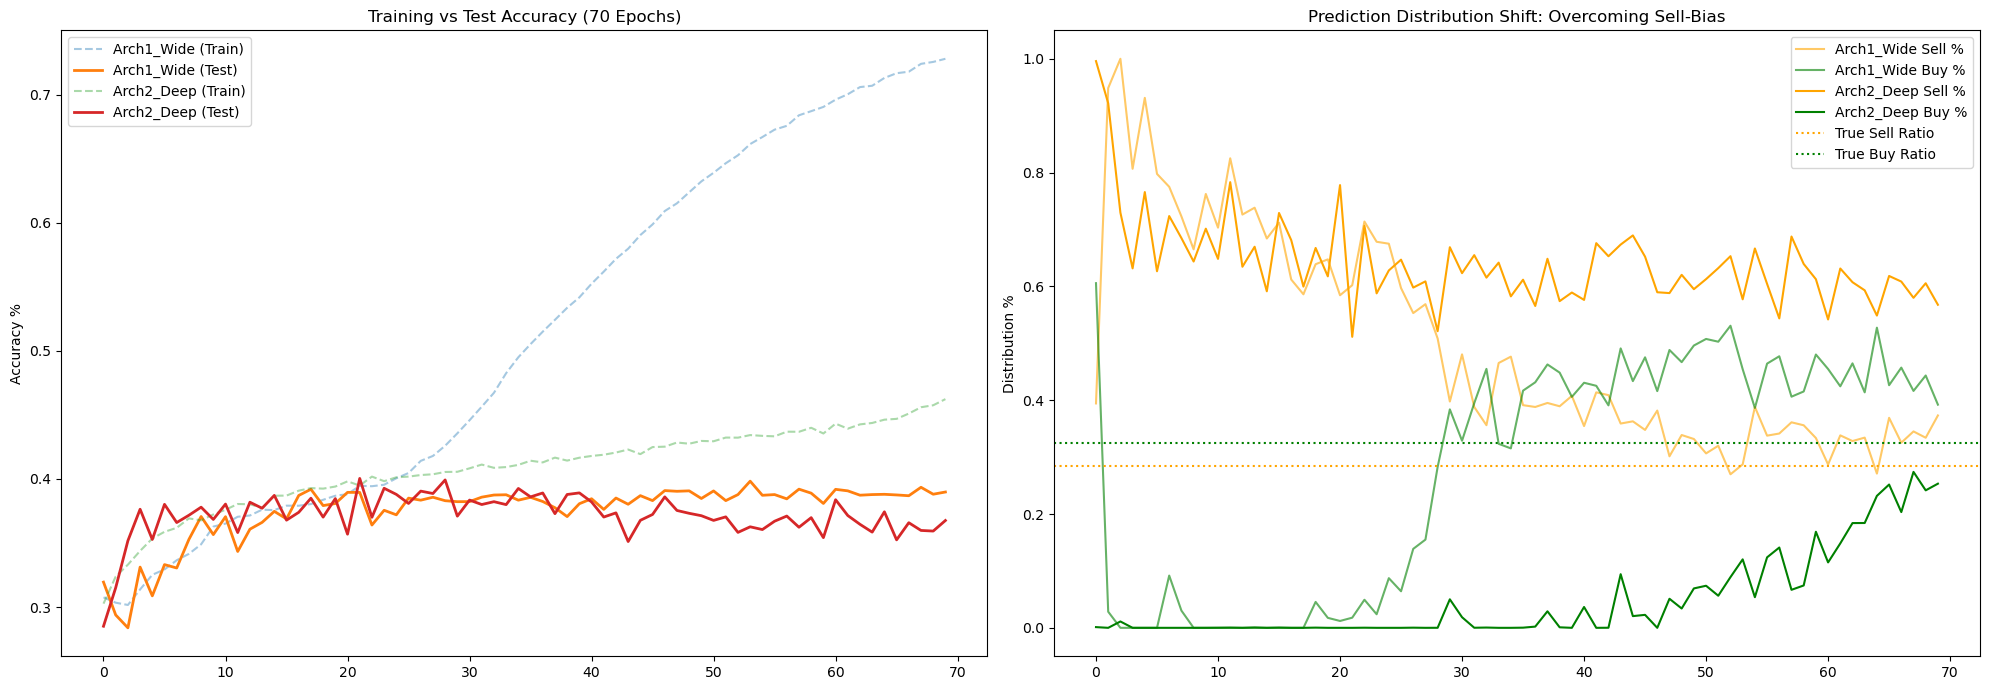

In [14]:
# ===== Cell 4: Dual-Architecture 70-Epoch Stress Test (Enforced Init) =====

def init_weights_sota(m):
    """
    Custom Xavier Initialization for SOTA TFT.
    Ensures Attention and LSTM layers are stabilized for chronological training.
    """
    if isinstance(m, nn.Linear):
        init.xavier_uniform_(m.weight)
        if m.bias is not None:
            init.zeros_(m.bias)
    elif isinstance(m, nn.LSTM):
        # Specific initialization for LSTM gates to prevent early collapse
        for name, param in m.named_parameters():
            if 'weight_ih' in name:
                init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                init.orthogonal_(param.data) # Orthogonal is better for deep LSTMs
            elif 'bias' in name:
                param.data.fill_(0)
                # Forget gate bias trick: set to 1 to help with long-term memory
                n = param.size(0)
                param.data[n//4:n//2].fill_(1.0)

# 1. PARAMETERS & PATHS
OPTIMAL_PARAMS = {
    'directional_weight': 0.6,
    'gamma': 1.5,
    'lr': 0.0005
}

# Resolve paths correctly for PyCharm
CHECKPOINT_DIR = Path("../scripts/best_runs/tft")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

arch_configs = [
    {"name": "Arch1_Wide", "hidden": 128, "layers": 1},
    {"name": "Arch2_Deep", "hidden": 64, "layers": 2}
]

# 2. TRAINING LOOP
all_arch_history = {}

for config in arch_configs:
    print(f"\n🏗️ Training {config['name']} on CPU (70 Epochs)...")

    # Initialize Model
    model = StockTFT(input_dim=7, hidden_dim=config['hidden'],
                     num_layers=config['layers'], n_heads=8).to('cpu')

    # ENFORCE GOOD INITIALIZATION
    model.apply(init_weights_sota)

    criterion = TFTLoss(alpha=class_weights, gamma=OPTIMAL_PARAMS['gamma'],
                         directional_weight=OPTIMAL_PARAMS['directional_weight'])
    optimizer = torch.optim.Adam(model.parameters(), lr=OPTIMAL_PARAMS['lr'], weight_decay=1e-4)

    history = {"train_acc": [], "test_acc": [], "sell_ratio": [], "neu_ratio": [], "buy_ratio": []}
    best_test_acc = 0

    for epoch in range(70):
        model.train()
        total_train, correct_train = 0, 0
        for xb, yb, _ in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            _, pred = torch.max(logits.data, 1)
            total_train += yb.size(0)
            correct_train += (pred == yb).sum().item()

        # Evaluation
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for xb, yb, _ in test_loader:
                logits = model(xb)
                _, pred = torch.max(logits, 1)
                all_preds.extend(pred.numpy())
                all_labels.extend(yb.numpy())

        # Metrics
        train_acc = correct_train / total_train
        test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
        pred_dist = np.bincount(all_preds, minlength=3) / len(all_preds)

        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["sell_ratio"].append(pred_dist[0])
        history["neu_ratio"].append(pred_dist[1])
        history["buy_ratio"].append(pred_dist[2])

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), CHECKPOINT_DIR / f"best_{config['name']}.pth")

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[{config['name']}] Ep {epoch+1}/70 | Test Acc: {test_acc:.1%}")
            print(f"  Pred Dist: S:{pred_dist[0]:.1%} N:{pred_dist[1]:.1%} B:{pred_dist[2]:.1%}")

    all_arch_history[config['name']] = history

# ... [plotting logic follows] ...

# --- PLOTTING: BIAS & PERFORMANCE ANALYSIS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Overfitting/Double Descent Check
for name, hist in all_arch_history.items():
    ax1.plot(hist['train_acc'], label=f"{name} (Train)", linestyle='--', alpha=0.4)
    ax1.plot(hist['test_acc'], label=f"{name} (Test)", linewidth=2)
ax1.set_title("Training vs Test Accuracy (70 Epochs)")
ax1.set_ylabel("Accuracy %")
ax1.legend()

# Plot 2: Prediction Distribution Evolution (Class Bias)
# We track how the 'Sell Bias' changes over time
true_dist = np.bincount(all_labels, minlength=3) / len(all_labels)
colors = ['orange', 'gray', 'green']
for i, name in enumerate(all_arch_history.keys()):
    hist = all_arch_history[name]
    ax2.plot(hist['sell_ratio'], color='orange', alpha=0.6 if i==0 else 1.0, label=f"{name} Sell %")
    ax2.plot(hist['buy_ratio'], color='green', alpha=0.6 if i==0 else 1.0, label=f"{name} Buy %")

ax2.axhline(y=true_dist[0], color='orange', linestyle=':', label='True Sell Ratio')
ax2.axhline(y=true_dist[2], color='green', linestyle=':', label='True Buy Ratio')
ax2.set_title("Prediction Distribution Shift: Overcoming Sell-Bias")
ax2.set_ylabel("Distribution %")
ax2.legend()

plt.tight_layout()
plt.show()

# ===== End of Cell 4 =====

In [15]:
import torch
from pathlib import Path

# --- 1. SET PATH ---
model_path = Path("..") / "results" / "best_runs" / "tft" / "final_models" / "Wide_Shallow_Standard_Final_best.pth"

def reconstruct_tft_config(path):
    if not path.exists():
        print(f"❌ Error: Model not found at {path.absolute()}")
        return

    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    state_dict = checkpoint.get('model_state_dict', checkpoint.get('state', checkpoint))
    config = checkpoint.get('config', {})

    # --- DEBUG: Print first 10 keys to verify naming ---
    print(f"🔍 Successfully opened: {path.name}")
    print("📋 Sample state_dict keys for verification:")
    for i, key in enumerate(list(state_dict.keys())[:10]):
        print(f"  {i}. {key}")

    try:
        # 1. Input Dimensions
        input_dim = 0
        # Use a more flexible check: look for any key containing 'feature_grns'
        grn_keys = [k for k in state_dict.keys() if 'feature_grns' in k and 'weight' in k]
        input_dim = len(set([k.split('feature_grns.')[1].split('.')[0] for k in grn_keys]))

        # 2. Hidden Dimensions (Find the first linear weight in the first GRN)
        # We find a key that looks like 'vsn.feature_grns.0.fc1.weight' even if it has a prefix
        hidden_key = [k for k in state_dict.keys() if 'feature_grns.0' in k and 'weight' in k][0]
        hidden_dim = state_dict[hidden_key].shape[0]

        # 3. Heads
        mha_key = [k for k in state_dict.keys() if 'mha.in_proj_weight' in k][0]
        embed_dim = state_dict[mha_key].shape[1]
        n_heads = config.get('heads', config.get('n_heads', embed_dim // 32))

        # 4. Classes
        clf_key = [k for k in state_dict.keys() if 'classifier.weight' in k][0]
        output_dim = state_dict[clf_key].shape[0]

        print(f"""
==================================================
🏗️  RECONSTRUCTED ARCHITECTURE
==================================================
StockTFT(
    input_dim={input_dim},
    hidden_dim={hidden_dim},
    n_heads={n_heads},
    output_dim={output_dim}
)
==================================================
""")
    except Exception as e:
        print(f"\n❌ Reconstruction Error: {e}")
        print("💡 TIP: Check the printed keys above. Your model might have a prefix like 'module.'")

if __name__ == "__main__":
    reconstruct_tft_config(model_path)

🔍 Successfully opened: Wide_Shallow_Standard_Final_best.pth
📋 Sample state_dict keys for verification:
  0. vsn.weight
  1. vsn.bias
  2. lstm.weight_ih_l0
  3. lstm.weight_hh_l0
  4. lstm.bias_ih_l0
  5. lstm.bias_hh_l0
  6. lstm.weight_ih_l0_reverse
  7. lstm.weight_hh_l0_reverse
  8. lstm.bias_ih_l0_reverse
  9. lstm.bias_hh_l0_reverse

❌ Reconstruction Error: list index out of range
💡 TIP: Check the printed keys above. Your model might have a prefix like 'module.'


In [16]:
import torch
from pathlib import Path

# --- 1. SET PATH ---
model_path = Path("..") / "results" / "best_runs" / "tft" / "final_models" / "Wide_Shallow_Standard_Final_best.pth"

def reconstruct_tft_config(path):
    if not path.exists():
        print(f"❌ Error: Model not found at {path.absolute()}")
        return

    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    state_dict = checkpoint.get('model_state_dict', checkpoint.get('state', checkpoint))
    config = checkpoint.get('config', {})

    print(f"🔍 Successfully opened: {path.name}")

    try:
        # 1. Input Dimensions: Taken from vsn.weight's input dimension
        # In PyTorch Linear layers, weight shape is [out_features, in_features]
        # Since it's a VSN, we check the second dimension.
        input_dim = state_dict['vsn.weight'].shape[1]

        # 2. Hidden Dimensions: Taken from vsn.weight's output dimension
        hidden_dim = state_dict['vsn.weight'].shape[0]

        # 3. Heads: Looking for Multihead Attention key (mha)
        # We find any key containing 'mha' to get the embed_dim
        mha_key = [k for k in state_dict.keys() if 'mha' in k and 'in_proj_weight' in k][0]
        embed_dim = state_dict[mha_key].shape[1]

        # Infer n_heads: usually embed_dim // 32
        n_heads = config.get('heads', config.get('n_heads', embed_dim // 32))

        # 4. Classes: Taken from classifier weight
        clf_key = [k for k in state_dict.keys() if 'classifier.weight' in k][0]
        output_dim = state_dict[clf_key].shape[0]

        arch_str = f"""
==================================================
🏗️  RECONSTRUCTED ARCHITECTURE (Vectorized VSN)
==================================================
StockTFT(
    input_dim={input_dim},
    hidden_dim={hidden_dim},
    n_heads={n_heads},
    output_dim={output_dim}
)
==================================================
🚀 HYPERPARAMETERS FOUND:
- LR: {config.get('lr', 'N/A')}
- Gamma: {config.get('gamma', 'N/A')}
- DW: {config.get('dw', 'N/A')}
==================================================
"""
        print(arch_str)

    except Exception as e:
        print(f"\n❌ Specific Reconstruction Error: {e}")
        print("Available keys were:", list(state_dict.keys())[:15])

if __name__ == "__main__":
    reconstruct_tft_config(model_path)

🔍 Successfully opened: Wide_Shallow_Standard_Final_best.pth

❌ Specific Reconstruction Error: list index out of range
Available keys were: ['vsn.weight', 'vsn.bias', 'lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'lstm.weight_ih_l0_reverse', 'lstm.weight_hh_l0_reverse', 'lstm.bias_ih_l0_reverse', 'lstm.bias_hh_l0_reverse', 'mha.in_proj_weight', 'mha.in_proj_bias', 'mha.out_proj.weight', 'mha.out_proj.bias', 'post_attn_grn.fc1.weight']


In [17]:
import torch
from pathlib import Path

# --- 1. SET PATH ---
model_path = Path("..") / "results" / "best_runs" / "tft" / "final_models" / "Wide_Shallow_Standard_Final_best.pth"

def reconstruct_tft_config(path):
    if not path.exists():
        print(f"❌ Error: Model not found at {path.absolute()}")
        return

    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    state_dict = checkpoint.get('model_state_dict', checkpoint.get('state', checkpoint))
    config = checkpoint.get('config', {})

    print(f"🔍 Analyzing Architechture for: {path.name}")

    try:
        # 1. Input Dimensions: Taken from vsn.weight (out_features, in_features)
        # The second dimension of the weight matrix is the number of input features.
        input_dim = state_dict['vsn.weight'].shape[1]

        # 2. Hidden Dimensions: Taken from vsn.weight output features
        hidden_dim = state_dict['vsn.weight'].shape[0]

        # 3. Heads: Search for Multihead Attention in_proj_weight
        mha_key = [k for k in state_dict.keys() if 'mha.in_proj_weight' in k][0]
        embed_dim = state_dict[mha_key].shape[1]

        # In your Bi-LSTM setup, embed_dim is hidden_dim * 2.
        # Heads are usually embed_dim // 32
        n_heads = config.get('heads', config.get('n_heads', embed_dim // 32))

        # 4. Output Dim: Search for the final classifier layer
        # If 'classifier' isn't in the keys, we look for the last linear layer in the dict
        clf_keys = [k for k in state_dict.keys() if 'weight' in k and ('classifier' in k or 'fc' in k)]
        if clf_keys:
            output_dim = state_dict[clf_keys[-1]].shape[0]
        else:
            # Fallback to the very last weight in the state_dict
            last_key = [k for k in state_dict.keys() if 'weight' in k][-1]
            output_dim = state_dict[last_key].shape[0]

        arch_str = f"""
==================================================
🏗️  RECONSTRUCTED ARCHITECTURE (Success Run)
==================================================
StockTFT(
    input_dim={input_dim},
    hidden_dim={hidden_dim},
    n_heads={n_heads},
    output_dim={output_dim}
)
==================================================
🚀 METADATA & HYPERPARAMETERS:
- LR: {config.get('lr', 'N/A')}
- Gamma: {config.get('gamma', 'N/A')}
- Directional Weight (DW): {config.get('dw', 'N/A')}
- Bi-Directional LSTM: YES (Confirmed by reverse keys)
==================================================
"""
        print(arch_str)

    except Exception as e:
        print(f"\n❌ Reconstruction Error: {e}")
        print("Debugging: Ensure the model file is not corrupted and matches the StockTFT class.")

if __name__ == "__main__":
    reconstruct_tft_config(model_path)

🔍 Analyzing Architechture for: Wide_Shallow_Standard_Final_best.pth

🏗️  RECONSTRUCTED ARCHITECTURE (Success Run)
StockTFT(
    input_dim=7,
    hidden_dim=128,
    n_heads=8,
    output_dim=3
)
🚀 METADATA & HYPERPARAMETERS:
- LR: N/A
- Gamma: N/A
- Directional Weight (DW): N/A
- Bi-Directional LSTM: YES (Confirmed by reverse keys)

